# 2.3.1 トークン埋め込みの確認
`nn.Embedding`を使ってトークンIDのベクトルから埋め込みベクトルの行列を作成  
トークンIDを埋め込みベクトルに変換する層を作って、実際にトークンIDを512次元ベクトルへ変換

(注意)  `nn.Embedding`でembeddingを作った直後は重みがランダムな初期値なので、ここで得られる埋め込みベクトルにはまだ言語的な意味はない状態。

In [31]:
import torch
from torch import nn

vocabulary_size = 100 # 語彙数
d_model = 512 # 埋め込み次元

# 埋め込み層を定義((100,512)の重み行列を持つ)
# 実際にはこの重みを適切に学習することで、トークンIDを意味のある埋め込みベクトルに変換できるようになる
embedding = nn.Embedding(vocabulary_size, d_model) 

# 本来は辞書ベースで単語とトークンIDを対応させるが、ここではトークンID=1,2,3を指定して埋め込みベクトルを取得する
tokens = torch.Tensor([1, 2, 3]).long() # トークンID=1,2,3を指定

embedding_vector = embedding(tokens) # トークンID=1,2,3に対応する埋め込みベクトルを取得

print(embedding_vector) # 埋め込みベクトルを表示

print(embedding_vector.shape) # 埋め込みベクトルを取得し形状を確認(512次元の埋め込みベクトルが3つ取得できる)

tensor([[ 0.1943,  0.6149, -0.8295,  ..., -1.2373,  1.1232,  0.0687],
        [ 0.2322, -1.0894, -0.7328,  ...,  0.6514,  0.8274, -0.6344],
        [-1.5887,  0.7429,  1.1890,  ..., -1.8939,  0.4508,  0.3649]],
       grad_fn=<EmbeddingBackward0>)
torch.Size([3, 512])


# 2.3.2 位置エンコーディングの実装

位置エンコーディングのベクトル値を格納したpe行列(sequence_length, d_model)を作成する
事前に`sequence_length`番目までの位置エンコーディングのベクトル値を用意しておき、`pe[i]`のように取得して使う

In [32]:
import torch
def sinusoidal_position_encoding(d_model: int, sequence_length: int) -> torch.Tensor:
    # d_model: 埋め込みベクトルの次元数
    # sequence_length: 入力文章の長さの上限(token数の上限)
    
    pe = torch.zeros(sequence_length, d_model) # (sequence_length, d_model)のゼロ行列を作成
    
    dim_even = torch.arange(0, d_model, 2) # 偶数の配列([0, 2, 4, ..., d_model-2])
    dim_odd = torch.arange(1, d_model, 2) # 奇数の配列([1, 3, 5, ..., d_model-1])

    # (1, sequence_length)のposition配列([[0], [1], [2], ...])を作成
    #   最終的にpe行列は(sequence_length, d_model)の形状である必要があるため(sequence_length, 1) の形にする
    pos = torch.arange(0, sequence_length).unsqueeze(1)

    pe[:, dim_even] = torch.sin(pos / (10000 ** (dim_even / d_model)))  # 偶数次元の位置エンコーディングを計算してpe行列に代入
    pe[:, dim_odd] = torch.cos(pos / (10000 ** ((dim_odd - 1) / d_model))) # 奇数次元の位置エンコーディングを計算してpe行列に代入

    # 先頭に次元を追加
    return pe.unsqueeze(0)

(参考) torch.arangeとunsqueeze

In [33]:
import torch
a = torch.tensor([[1, 2, 3, 4, 5], 
                  [6, 7, 8, 9, 10], 
                  [11, 12, 13, 14, 15], 
                  [16, 17, 18, 19, 20], 
                  [21, 22, 23, 24, 25]])
print("a: \n", a)

a = a.unsqueeze(0) # 先頭に次元を追加し(1,5,5)の形に変換
print("a.unsqueeze(0): \n", a)
print("a.unsqueeze(0).shape: \n", a.shape)

a = a[0] # (5,5)の形に変換(元に戻す)

print("a[:, 2]: ", a[:, 2]) # 2番目の列を指定して取得

# 複数の列や行を指定して取得
index = torch.tensor([0, 2, 4]) # 0,2,4番目を指定
print("a[:, index]: ", a[:, index]) # index番目の列を取得
print("a[index, :]: ", a[index, :]) # index番目の行を取得

n_len = 5
b = torch.arange(0, n_len) # 0からn_len-1までの整数を生成する
print("b: ", b)

print("b.unsqueeze(1): \n", b.unsqueeze(1)) # (5,1)の形に変換


a: 
 tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20],
        [21, 22, 23, 24, 25]])
a.unsqueeze(0): 
 tensor([[[ 1,  2,  3,  4,  5],
         [ 6,  7,  8,  9, 10],
         [11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20],
         [21, 22, 23, 24, 25]]])
a.unsqueeze(0).shape: 
 torch.Size([1, 5, 5])
a[:, 2]:  tensor([ 3,  8, 13, 18, 23])
a[:, index]:  tensor([[ 1,  3,  5],
        [ 6,  8, 10],
        [11, 13, 15],
        [16, 18, 20],
        [21, 23, 25]])
a[index, :]:  tensor([[ 1,  2,  3,  4,  5],
        [11, 12, 13, 14, 15],
        [21, 22, 23, 24, 25]])
b:  tensor([0, 1, 2, 3, 4])
b.unsqueeze(1): 
 tensor([[0],
        [1],
        [2],
        [3],
        [4]])


In [34]:
# from llm_from_scratch.transformer.utils import sinusoidal_position_encoding

In [35]:
d_model = 128 # 埋め込みベクトル次元 = 位置エンコーディングの次元
sequence_length = 100 # トークン列(≒文章)の長さ

# 位置エンコーディングを作成(位置100個分)
pe = sinusoidal_position_encoding(d_model=d_model, sequence_length=sequence_length)
pe = pe[0]
print(pe.shape) # 位置エンコーディングの形状を確認

# 例: 5文字目の位置エンコーディングを表示
print(pe[4]) # この値が5文字目の埋め込みベクトルに足される
print(pe[4].shape) # 位置エンコーディングの次元数を確認(128次元)
print(pe.shape)

torch.Size([100, 128])
tensor([-7.5680e-01, -6.5364e-01, -3.1672e-01, -9.4852e-01,  1.4154e-01,
        -9.8993e-01,  5.1762e-01, -8.5561e-01,  7.7847e-01, -6.2768e-01,
         9.2975e-01, -3.6820e-01,  9.9328e-01, -1.1573e-01,  9.9395e-01,
         1.0988e-01,  9.5358e-01,  3.0114e-01,  8.8910e-01,  4.5772e-01,
         8.1257e-01,  5.8286e-01,  7.3211e-01,  6.8119e-01,  6.5283e-01,
         7.5751e-01,  5.7775e-01,  8.1621e-01,  5.0847e-01,  8.6108e-01,
         4.4566e-01,  8.9520e-01,  3.8942e-01,  9.2106e-01,  3.3950e-01,
         9.4061e-01,  2.9548e-01,  9.5535e-01,  2.5684e-01,  9.6645e-01,
         2.2304e-01,  9.7481e-01,  1.9356e-01,  9.8109e-01,  1.6788e-01,
         9.8581e-01,  1.4555e-01,  9.8935e-01,  1.2615e-01,  9.9201e-01,
         1.0932e-01,  9.9401e-01,  9.4713e-02,  9.9550e-01,  8.2049e-02,
         9.9663e-01,  7.1071e-02,  9.9747e-01,  6.1558e-02,  9.9810e-01,
         5.3316e-02,  9.9858e-01,  4.6175e-02,  9.9893e-01,  3.9989e-02,
         9.9920e-01,  3.4632

## 位置エンコーディングベクトルの特徴
- 低次元ほど位置による変化が大きく、高次元ほど位置による変化が小さい
- 近い位置ベクトルの内積は大きく、遠い位置ベクトルの内積は小さい

位置によって異なるベクトルになっていることを確認  
低次元ほど位置による変化が大きく、高次元ほど位置による変化が小さい

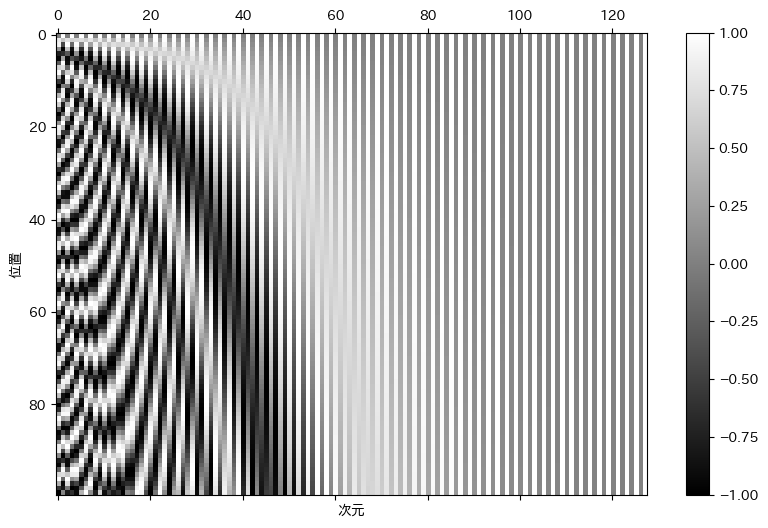

In [36]:
import matplotlib.pyplot as plt
import japanize_matplotlib

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.matshow(pe, cmap="gray")
fig.colorbar(cax)
ax.set_xlabel("次元")
ax.set_ylabel("位置")
fig.savefig("sinusoidal_position_encoding.png", bbox_inches="tight")
plt.show()

2つの位置(i,j)エンコーディングの内積を計算し、それぞれの位置に応じた内積の大きさを確認  
位置が近いほど内積が大きく、位置が遠いほど内積が小さいことがわかる

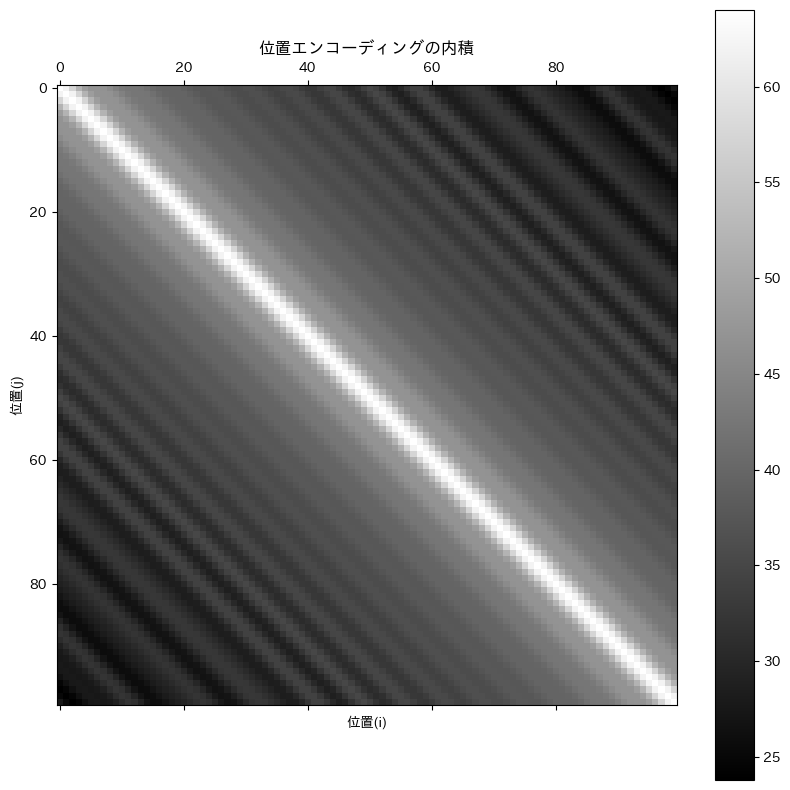

In [37]:
import torch

dotprod = torch.matmul(pe, pe.transpose(0, 1)) # 位置エンコーディング同士の内積を計算

fig, ax = plt.subplots(figsize=(10, 10))

cax = ax.matshow(dotprod, cmap="gray")
fig.colorbar(cax)
ax.set_title("位置エンコーディングの内積")
ax.set_xlabel("位置(i)")
ax.set_ylabel("位置(j)")
fig.savefig("sinusoidal_position_encoding_dotprod.png", bbox_inches="tight")
plt.show()

`sinusoidal_position_encoding`を使って2つの位置エンコーディングを作成し、内積を計算した結果と、位置エンコーディングの内積の論理値を計算した結果を比較してみる

In [38]:
# 位置エンコーディングの内積の論理値を計算
import numpy as np

dots = np.zeros(sequence_length)
for pos in range(sequence_length):
    total = 0
    for d in range(d_model // 2):
        total += np.cos(pos / (10000 ** (2 * d / d_model)))  # PE_iとPE_jの内積の計算(論理式)
    dots[pos] = total

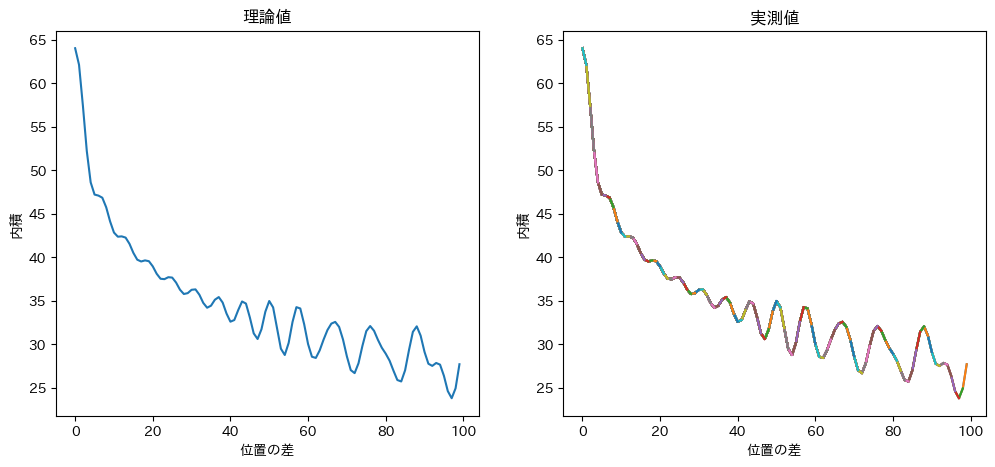

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(dots)
ax[1].plot(dots)
for i in range(sequence_length):
    ax[1].plot(dotprod[i, i:])
ax[0].set_xlabel("位置の差")
ax[1].set_xlabel("位置の差")
ax[0].set_title("理論値")
ax[1].set_title("実測値")
ax[0].set_ylabel("内積")
ax[1].set_ylabel("内積")
plt.show()

# 2.3.3 フィードフォワード層(FFN)
Attention出力(O')をレイヤー正規化したものを入力とするFFNを実装

In [40]:
import torch
from torch import nn

d_model = 512 # 入力ベクトルの次元
d_ff = d_model * 4 # FFNの中間出力ベクトルの次元

feed_forward = nn.Sequential( # ニューラルネットワークの定義
    nn.Linear(d_model, d_ff),
    nn.ReLU(),
    nn.Linear(d_ff, d_model),
)

x = torch.randn(1, 10, d_model)
print("input shape:", x.shape)

y = feed_forward(x).shape # xの各ベクトルをそれぞれFFNに入力して出力を得る
print("output shape:", y)

input shape: torch.Size([1, 10, 512])
output shape: torch.Size([1, 10, 512])


# 2.3.4 スキップ接続
ブロック(マルチヘッドアテンションやFFN)の出力に入力を足すスキップ接続を実装

In [41]:
import torch
from torch import nn

class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super(FFN, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(torch.relu(self.linear1(x)))


class SkipConnection(nn.Module):
    def __init__(self, d_model, d_ff):
        super(SkipConnection, self).__init__()
        self.sublayer = FFN(d_model, d_ff)

    def forward(self, x):
        return x + self.sublayer(x) # 入力xをFNNに通した出力に入力xを足す

入力と出力が同じになるように学習  
スキップ接続あり/なしの場合の学習曲線を比較してみる

In [42]:
# 恒等関数の学習
from tqdm.auto import tqdm

n_epochs = 100 # エポック数
N = 10000 # データ数
data = torch.randn(N, 10) # 入力次元10のランダムなデータをN個生成

# 入力次元10、出力次元128のモデルを定義
model1 = FFN(10, 128) # FFNのみのモデルを定義(スキップ接続なし)
model2 = SkipConnection(10, 128) # スキップ接続ありのモデルを定義

criterion = nn.MSELoss() # 損失関数を定義(平均2乗誤差)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001) # model1のパラメータを更新するためのオプティマイザを定義
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001) # model2のパラメータを更新するためのオプティマイザを定義

pbar = tqdm(total=n_epochs, position=0) # エポック数分のプログレスバーを作成
loss1_history = []
loss2_history = []
for epoch in range(n_epochs):
    pbar.update(1)

    # 勾配を初期化
    optimizer1.zero_grad()
    optimizer2.zero_grad()

    # モデルの出力と入力データの差を損失として計算
    loss1 = criterion(model1(data), data)
    loss2 = criterion(model2(data), data)

    # 勾配を計算
    loss1.backward()
    loss2.backward()

    # パラメータを更新
    optimizer1.step()
    optimizer2.step()

    # 学習曲線を保存
    loss1_history.append(loss1.item())
    loss2_history.append(loss2.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {loss1.item()}, {loss2.item()}")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: 1.1428515911102295, 0.06279503554105759
Epoch 10: 0.8657551407814026, 0.019898969680070877
Epoch 20: 0.6463636159896851, 0.008905827067792416
Epoch 30: 0.46796756982803345, 0.006322783417999744
Epoch 40: 0.3243977129459381, 0.004870297387242317
Epoch 50: 0.21331222355365753, 0.0038316254504024982
Epoch 60: 0.1328013688325882, 0.0030681993812322617
Epoch 70: 0.07986410707235336, 0.0025143777020275593
Epoch 80: 0.04922712966799736, 0.0020976883824914694
Epoch 90: 0.03386786952614784, 0.0017758021131157875


学習曲線を比較  
スキップ接続ありのモデルの方が収束が早い

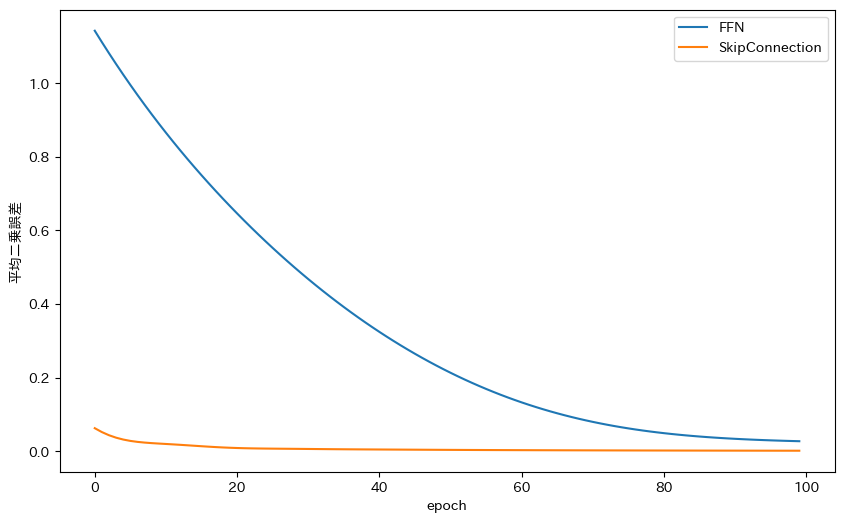

In [43]:
import matplotlib.pyplot as plt
import japanize_matplotlib

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(loss1_history, label="FFN")
ax.plot(loss2_history, label="SkipConnection")
ax.set_xlabel("epoch")
ax.set_ylabel("平均二乗誤差")
ax.legend()

fig.savefig("skip_connection_loss.png", bbox_inches="tight")
plt.show()

# 2.3.5 レイヤー正規化(実際にやってるのは標準化)
ニューラルネットワークのレイヤー(層)毎に出力の平均を0,分散を1に標準化するレイヤー正規化を実装。  
内部共変量シフト(レイヤごとに入力値の分布が変わること)を抑え、学習しやすくする。  

In [44]:
import torch

# 3つのトークンからなる文章を想定して埋め込みベクトルを生成
sentence_length, embedding_dim = 3, 5
embedding = torch.randn(sentence_length, embedding_dim)
print("embedding:", embedding)

# 平均と標準偏差を計算
mean = embedding.mean(axis=[-1], keepdim=True) # 平均(横方向)
print("mean:", mean)
std = embedding.std(axis=[-1], keepdim=True, unbiased=False) # 標準偏差(横方向)
print("std:", std)

# 標準化
eps = 1e-8 # 標準偏差が0になるのを防ぐための微小な値
normalized_embedding = (embedding - mean) / std.add(eps)
print("normalized_embedding:", normalized_embedding)

# 各行の平均と標準偏差を確認(それぞれ0と1になるはず)
print("normalized_embedding mean:", normalized_embedding.mean(axis=[-1])) # 各行の平均
print("normalized_embedding std:", normalized_embedding.std(axis=[-1], unbiased=False)) # 各行の標準偏差


embedding: tensor([[-0.5159, -0.2264, -0.1868,  0.0529,  0.6796],
        [ 0.3626, -0.0907, -0.2210, -0.4891,  0.1863],
        [ 0.0375, -1.1386,  0.7520,  0.2439, -0.3856]])
mean: tensor([[-0.0393],
        [-0.0504],
        [-0.0982]])
std: tensor([[0.4023],
        [0.2999],
        [0.6361]])
normalized_embedding: tensor([[-1.1846, -0.4650, -0.3666,  0.2291,  1.7871],
        [ 1.3770, -0.1343, -0.5689, -1.4628,  0.7890],
        [ 0.2133, -1.6355,  1.3365,  0.5377, -0.4519]])
normalized_embedding mean: tensor([-2.0862e-08,  2.3842e-08,  0.0000e+00])
normalized_embedding std: tensor([1.0000, 1.0000, 1.0000])


バッチ込みでやるパターン

In [45]:
import torch

batch, sentence_length, embedding_dim = 20, 5, 10

# 埋め込みベクトルを擬似的に生成
embedding = torch.randn(batch, sentence_length, embedding_dim)

mean = embedding.mean(axis=[-1], keepdim=True) # 平均
std = embedding.std(axis=[-1], keepdim=True, unbiased=False) 

# 標準化
eps = 1e-8
normalized_embedding = (embedding - mean) / std.add(eps)

# 3番目の文の2番目の単語位置の特徴ベクトルを取得
feature_vector = normalized_embedding[3, 2, :]
print(feature_vector.mean(), feature_vector.std(unbiased=False))

tensor(-2.3842e-08) tensor(1.)
